# 12.3.2 选择变异与机制消融

## 学习目标与先修知识

分别启停选择与变异，区分期望（expectation）频率和随机轨迹（trajectory）。

先修：12.3.1 二项抽样方差（variance）；12.2 收益与频率；5.1 重复实验。

In [ ]:
from systems_science.local_service import notebook_service_ready
notebook_service_ready()

## 具体问题

观察到一种类型频率上升，可以是选择、变异、漂变的共同结果。怎样按固定次序分别打开机制，并避免把下一代随机计数当成期望值？

In [1]:
import math
import random
import numpy as np
import matplotlib.pyplot as plt
from matplotlib import font_manager
from systems_science import plot_style, show_table
plot_style()
font_names = {font.name for font in font_manager.fontManager.ttflist}
for name in ("Microsoft YaHei", "SimHei", "Noto Sans CJK SC"):
    if name in font_names:
        plt.rcParams["font.sans-serif"] = [name, "DejaVu Sans"]
        break
BLUE, PINK, GREEN = "#008bfb", "#ff0051", "#00a56a"

## 初步实验

设 p=.5、类型0适合度加成 s=1，先手算选择后 p=2/3，再加入双向变异。

In [2]:
print('p=.5、s=1 → 选择后2/3；变异后再按给定随机表抽样。')

p=.5、s=1 → 选择后2/3；变异后再按给定随机表抽样。


## 模型假设

类型0相对适合度1+s，类型1为1；先选择、再双向变异、最后独立抽 N 位后代。s≥0，两方向变异率在[0,1]。这是条件化教学顺序，不意味着演化有预设目标。

## 数学解释与推导

选择后的频率 $p_s=p(1+s)/(1+sp)$；变异后的期望频率 $p_m=p_s(1-\mu_{01})+(1-p_s)\mu_{10}$；实际下一代计数在给定 $p_m$ 下二项抽样。$p=0$ 且 $\mu_{10}>0$ 时 $p_m>0$，但有限抽样仍可能得到0。逐项把 $s$ 或 $\mu$ 置零，再比较重复实验的分布（distribution），就能观察各机制在模型（model）中的作用。

## 核心实现

下面将本节推导写成可运行函数。

In [3]:
def neutral_step(p, draws):
    """One Wright-Fisher-style generation with supplied independent U[0,1) draws."""
    return sum(value < p for value in draws) / len(draws)


def selected_mutated_step(p, selection, mutation_01, mutation_10, draws):
    """Type-0 selection, then bidirectional mutation, then finite sampling."""
    selected = p * (1 + selection) / (1 + selection * p)
    mutated = selected * (1 - mutation_01) + (1 - selected) * mutation_10
    return [selected, mutated, neutral_step(mutated, draws)]

## 对照实验

从同一初态比较中性、仅选择与选择加变异；每组80条、每条30代，用共同抽样种子表。

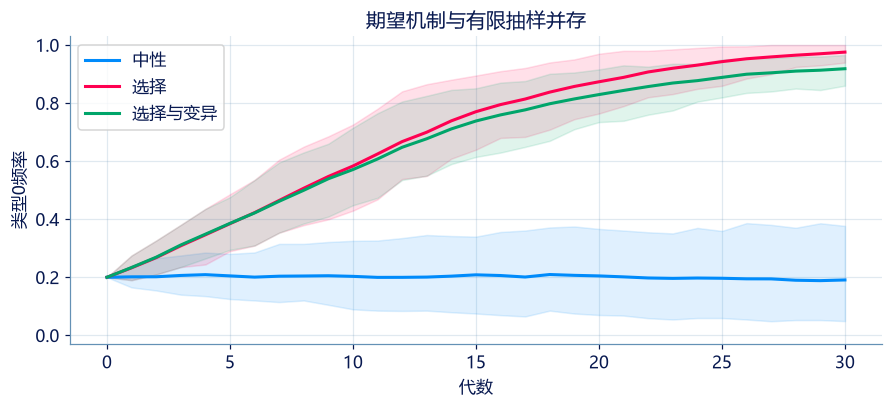

In [4]:
N=200;R=80;H=30;p0=.2;conditions={'中性':(0.,0.,0.),'选择':(.2,0.,0.),'选择与变异':(.2,.01,.005)}
streams=np.random.default_rng(1232).random((R,H,N));runs={}
for name,(s,m01,m10) in conditions.items():
    rows=[]
    for r in range(R):
        p=p0;path=[p]
        for t in range(H):
            p=selected_mutated_step(p,s,m01,m10,streams[r,t])[2]
            path.append(p)
        rows.append(path)
    runs[name]=np.asarray(rows)
fig,ax=plt.subplots(figsize=(8,3.6))
for color,(name,rows) in zip([BLUE,PINK,GREEN],runs.items()):
    mean=rows.mean(axis=0);low,high=np.quantile(rows,[.1,.9],axis=0)
    ax.plot(range(H+1),mean,label=name,color=color);ax.fill_between(range(H+1),low,high,color=color,alpha=.12)
ax.set(xlabel='代数',ylabel='类型0频率',ylim=(-.03,1.03),title='期望机制与有限抽样并存')
ax.legend();plt.show()

## 结果解释

阴影反映固定条件下的有限种群波动；比较的是人工机制组合，不是对生物群落的直接归因。有变异时的期望可离开0，但实际抽样仍可能在某代为0。

### 独立核对

检验 s=μ=0 退回中性抽样；手算先后顺序与零边界。

In [5]:
draws=[.1,.5,.8,.9]
selected,mutated,sampled=selected_mutated_step(.5,1.,.1,.2,draws)
np.testing.assert_allclose(selected,2/3)
np.testing.assert_allclose(mutated,(2/3)*.9+(1/3)*.2)
assert sampled==neutral_step(mutated,draws)
assert selected_mutated_step(0.,0.,0.,.25,[.1,.3,.8,.9])[1]==.25
print('机制顺序、抽样退化及变异边界核验通过。')

机制顺序、抽样退化及变异边界核验通过。


## 练习与参考资料

先独立作答，再提交核对。

### 第 1 题 · Python 计算题：选择、变异再抽样

类型0相对适合度为1+selection，类型1为1。先按适合度加权得到选后频率；再以 mutation_01 使类型0转向1、mutation_10 使类型1转向0；最后用给定 draws 抽样下一代。依次返回选后、变异后和抽样后频率。

**函数与代码模板**

```python
def solve(
    p: float,
    selection: float,
    mutation_01: float,
    mutation_10: float,
    draws: list[float],
) -> tuple[float, float, float]:
    # 按题意计算并返回结果。
    raise NotImplementedError("请完成计算")
```

**参数说明**

| 名称 | Python 类型 | 含义 | 单位 |
|---|---|---|---|
| `p` | `float` | 更新前类型0频率。 | 1 |
| `selection` | `float` | 类型0相对选择系数，≥0。 | 1 |
| `mutation_01` | `float` | 类型0转类型1概率（probability）。 | 1 |
| `mutation_10` | `float` | 类型1转类型0概率。 | 1 |
| `draws` | `list[float]` | 下一代固定均匀抽样表。 | 1 |

**返回值**

按以下顺序返回元组：(selected, mutated, sampled)。

| 名称 | Python 类型 | 含义 | 单位 |
|---|---|---|---|
| `selected` | `float` | 选择后的期望（expectation）频率。 | 1 |
| `mutated` | `float` | 双向变异后的期望频率。 | 1 |
| `sampled` | `float` | 有限抽样后的实际频率。 | 1 |

**计算规则**

selected=p(1+s)/(1+sp)，mutated=selected(1−μ01)+(1−selected)μ10，sampled=抽样值小于 mutated 的比例。

**约束与边界**

- 只使用题定的有限状态（state）、固定输入（input）与明示更新规则；不从图形猜测答案。

**输入样例**

每个参数对应函数签名中的同名变量；单位与顺序见下表。

给定条件

| 参数 | 含义 | 给定值 | 单位 |
| --- | --- | --- | --- |
| p | 更新前类型0频率。 | 0.5 | 1 |
| selection | 类型0相对选择系数，≥0。 | 1 | 1 |
| mutation_01 | 类型0转类型1概率（probability）。 | 0.1 | 1 |
| mutation_10 | 类型1转类型0概率。 | 0.2 | 1 |
| draws | 下一代固定均匀抽样表。 | [0.1, 0.5, 0.8, 0.9] | 1 |

**输入与调用代码**

完成 solve 函数后，将下面的参数赋值与调用代码放在函数定义下方运行。

```python
p = 0.5
selection = 1.0
mutation_01 = 0.1
mutation_10 = 0.2
draws = [0.1, 0.5, 0.8, 0.9]

result = solve(p, selection, mutation_01, mutation_10, draws)
print(result)
```

**输出样例**

对这组输入，你的函数应返回下列结果。列表按表格自上而下的顺序排列；标有“≈”的是便于阅读的近似值，请按模型计算完整数值。

计算结果

| 返回项 | 含义 | 结果 | 单位 |
| --- | --- | --- | --- |
| selected | 选择后的期望（expectation）频率。 | ≈ 0.6666667 | 1 |
| mutated | 双向变异后的期望频率。 | ≈ 0.6666667 | 1 |
| sampled | 有限抽样后的实际频率。 | 0.5 | 1 |

**预期输出代码**

用 expected_output 对照 result 的类型、顺序与数值。代码保留样例原始精度，浮点结果按题面容差比较。

```python
expected_output = (0.6666666666666666,
                   0.6666666666666666,
                   0.5)
```

**样例解释**

选择改变期望频率，变异引入双向流，有限抽样可能偏离期望；三步不能混写。

允许 Python 标准库；绝对误差 1e-08 或相对误差 1e-07。

[作答：选择、变异再抽样](http://127.0.0.1:8000/chapters/12-03-%E9%80%89%E6%8B%A9%E3%80%81%E5%8F%98%E5%BC%82%E4%B8%8E%E9%80%82%E5%BA%94/practice/?question=p12-selection-mutation-draw)

### 第 2 题 · 单项选择题：适应不是预先目标

哪句话符合这里的选择模型（model）？

- **A.** 给定当前频率与适合度后，后代分布（distribution）改变；没有预定目标状态（state）。
- **B.** 系统为了适应而主动选择最优突变。
- **C.** 一次固定就证明未来环境永不改变。
- **D.** 选择与随机抽样是同一步的同一量。

[作答：适应不是预先目标](http://127.0.0.1:8000/chapters/12-03-%E9%80%89%E6%8B%A9%E3%80%81%E5%8F%98%E5%BC%82%E4%B8%8E%E9%80%82%E5%BA%94/practice/?question=p12-selection-no-goal)

### 第 3 题 · 单项选择题：有变异时的零边界

当前 p=0，mutation_10>0。哪项成立？

- **A.** 变异后期望（expectation）频率大于0，但有限抽样仍可能得到0。
- **B.** 下一代必有类型0。
- **C.** 零边界仍是严格吸收态（absorbing state）。
- **D.** 选择系数 alone 会从0产生类型0。

[作答：有变异时的零边界](http://127.0.0.1:8000/chapters/12-03-%E9%80%89%E6%8B%A9%E3%80%81%E5%8F%98%E5%BC%82%E4%B8%8E%E9%80%82%E5%BA%94/practice/?question=p12-mutation-boundary)

### 第 4 题 · 单项选择题：如何消融机制

想分辨选择、变异、漂变的影响，哪种实验设计更合适？

- **A.** 依次将 s、μ 置零，在相同 N 与重复预算下比较。
- **B.** 同时改变 N、s、μ 再归因于 s。
- **C.** 只看单次终点并倒推唯一机制。
- **D.** 删掉随机种子（random seed）记录。

[作答：如何消融机制](http://127.0.0.1:8000/chapters/12-03-%E9%80%89%E6%8B%A9%E3%80%81%E5%8F%98%E5%BC%82%E4%B8%8E%E9%80%82%E5%BA%94/practice/?question=p12-mechanism-ablation)

**进一步阅读**

[SFI Complexity Explorer 的复杂系统课程](https://www.complexityexplorer.org/courses/185-introduction-to-complexity/faq)提供演化主题；本节概率顺序均由题定机制导出。